# Prova 2 - Paradigmas de aprendizado de maquina
---
## Aluno: João Vittor de Araujo Alves 
## Matrícula: 20230145919


## Análise inicial e pré-processamento
---
### Importando bibliotecas

In [235]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importando dataset e analisando os dados 
- tamanho do dataset: linhas x colunas
- informações de quantidade por coluna e tipo de dados

In [236]:
df_diabetic = pd.read_csv('../Dados/Dados_brutos/diabetic_data.csv')
df_ids = pd.read_csv('../Dados/Dados_brutos/IDS_mapping.csv')

## Mesclagem com rótulos de IDS
Vamos adicionar descrições legíveis para as colunas `admission_type_id`, `discharge_disposition_id` e `admission_source_id`.

In [237]:
# Mapear IDs para descrições legíveis
mapping_admission_type = pd.DataFrame({
    'admission_type_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'admission_type': [
        'Emergency', 'Urgent', 'Elective', 'Newborn',
        'Not Available', 'NULL', 'Trauma Center', 'Not Mapped'
    ]
})

mapping_discharge = pd.DataFrame({
    'discharge_disposition_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
    'discharge_disposition': [
        'Discharged to home',
        'Discharged/transferred to another short term hospital',
        'Discharged/transferred to SNF',
        'Discharged/transferred to ICF',
        'Discharged/transferred to another type of inpatient care institution',
        'Discharged/transferred to home with home health service',
        'Left AMA',
        'Discharged/transferred to home under care of Home IV provider',
        'Admitted as an inpatient to this hospital',
        'Neonate discharged to another hospital for neonatal aftercare',
        'Expired',
        'Still patient or expected to return for outpatient services',
        'Hospice / home',
        'Hospice / medical facility',
        'Discharged/transferred within this institution to Medicare approved swing bed',
        'Discharged/transferred/referred another institution for outpatient services',
        'Discharged/transferred/referred to this institution for outpatient services',
        'NULL',
        'Expired at home. Medicaid only, hospice.',
        'Expired in a medical facility. Medicaid only, hospice.',
        'Expired, place unknown. Medicaid only, hospice.',
        'Discharged/transferred to another rehab fac including rehab units of a hospital .',
        'Discharged/transferred to a long term care hospital.',
        'Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.',
        'Not Mapped',
        'Unknown/Invalid',
        'Discharged/transferred to another federal health care facility.',
        'Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital',
        'Discharged/transferred to a Critical Access Hospital (CAH).',
        'Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere'
    ]
})

mapping_admission_source = pd.DataFrame({
    'admission_source_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26],
    'admission_source': [
        'Physician Referral', 'Clinic Referral', 'HMO Referral', 'Transfer from a hospital',
        'Transfer from a Skilled Nursing Facility (SNF)',
        'Transfer from another health care facility', 'Emergency Room', 'Court/Law Enforcement',
        'Not Available', 'Transfer from critial access hospital', 'Normal Delivery', 'Premature Delivery',
        'Sick Baby', 'Extramural Birth', 'Not Available', 'NULL',
        'Transfer From Another Home Health Agency', 'Readmission to Same Home Health Agency',
        'Not Mapped', 'Unknown/Invalid',
        'Transfer from hospital inpt/same fac reslt in a sep claim',
        'Born inside this hospital', 'Born outside this hospital',
        'Transfer from Ambulatory Surgery Center', 'Transfer from Hospice'
    ]
})

# Juntar as descrições ao dataset principal
# O resultado fica em df_merged para usar a partir deste ponto

df_merged = (
    df_diabetic
    .merge(mapping_admission_type, on='admission_type_id', how='left')
    .merge(mapping_discharge, on='discharge_disposition_id', how='left')
    .merge(mapping_admission_source, on='admission_source_id', how='left')
)

print('Merge concluído: dados com rótulos adicionados')
print('df_merged shape:', df_merged.shape)

# Usar o DataFrame mesclado como base para o restante do notebook
df_diabetic = df_merged

df_diabetic.head()

Merge concluído: dados com rótulos adicionados
df_merged shape: (101766, 53)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,NO,NULL,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room


## Dataset diabetes

Análise inicial do datset demosntra a existencia de muitos valores nulos indicados com "?" e alguns sendo string indicando intervalos numéricos, no momento do tratamento de dados, será analisado como lidar com esses nulos e transformar os intervalos em variável numerica.

In [238]:
df_diabetic.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,NO,NULL,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room


In [239]:
df_diabetic.shape

(101766, 53)

### Na soma dos valores nulos não esta contabilizando os valores = "?" por se tratar de uma string, mas que esta representando valor nulo e por isso mais a frente deve ser transformado de "?" para ser na verdade um valor NaN para depois trata-lo junto com outros valores ausentes.

In [240]:
df_diabetic.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### A partir da função abaixo é observado as colunas que tem valores nulos representados por "?" e a quantidade total em cada um.

In [241]:
(df_diabetic == '?').sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
encounter_id                    0
age                             0
gender                          0
admission_source_id             0
admission_type_id               0
num_lab_procedures              0
time_in_hospital                0
discharge_disposition_id        0
num_procedures                  0
number_emergency                0
number_outpatient               0
num_medications                 0
number_inpatient                0
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### No dataset em questao não existe problemas com duplicatas, sendo o total de zero.

In [242]:
df_diabetic.duplicated().sum()
df_diabetic.drop_duplicates(inplace=True)

## Informações sobre os dados
Analisando a função info() abaixo do dataset, observa-se que existem 50 colunas e grande parte delas sao do tipo categóricas, sendo necessário a transformação para colunas numéricas para serem utilizadas no modelo mais a frente.

In [243]:
df_diabetic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [244]:
df_diabetic.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Dataset IDS
Apos a analise foi observado que  ele contem a dimensao de 67x2 e suas duas colunas tem dados do tipo categórico, sendo apenas 7 ausentes no total das duas colunas e existe 1 duplicata apenas que deve ser removida.

In [245]:
df_ids.head()

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


In [246]:
df_ids.shape

(67, 2)

In [247]:
df_ids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   admission_type_id  65 non-null     object
 1   description        62 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [248]:
df_ids.isnull().sum()

admission_type_id    2
description          5
dtype: int64

In [249]:
df_ids.duplicated().sum()

np.int64(1)

In [250]:
df_ids = df_ids.drop_duplicates(inplace=True)
print("Duplicatas removidas do dataset de IDs.")

Duplicatas removidas do dataset de IDs.


# 1 EDA dataset df_diabetic
---

## 1.1 Ánalise de tipos de atributos

In [251]:
# 1) Tipos e separação categoria/numérico
print("Tipos de atributos:\n", df_diabetic.dtypes.value_counts())
cat_cols = df_diabetic.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_diabetic.select_dtypes(include=['number']).columns.tolist()
print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

Tipos de atributos:
 object    40
int64     13
Name: count, dtype: int64
Categóricas: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'admission_type', 'discharge_disposition', 'admission_source']
Numéricas: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


## 1.2 Análise de valores ausentes
---
### Covertendo a string "?" para valores NaN.

In [252]:
df_diabetic = df_diabetic.replace('?', np.nan)

#### Depois de trasnformar "?" em NaN, observou-se que colunas como weight que antes demonstrava ter 0 valores nulos, se trasnformou na coluna com mais valores ausentes, mostrando que "?" era uma amostra grande dos valores ausentes que nao estavm sendo detectados por ser string.

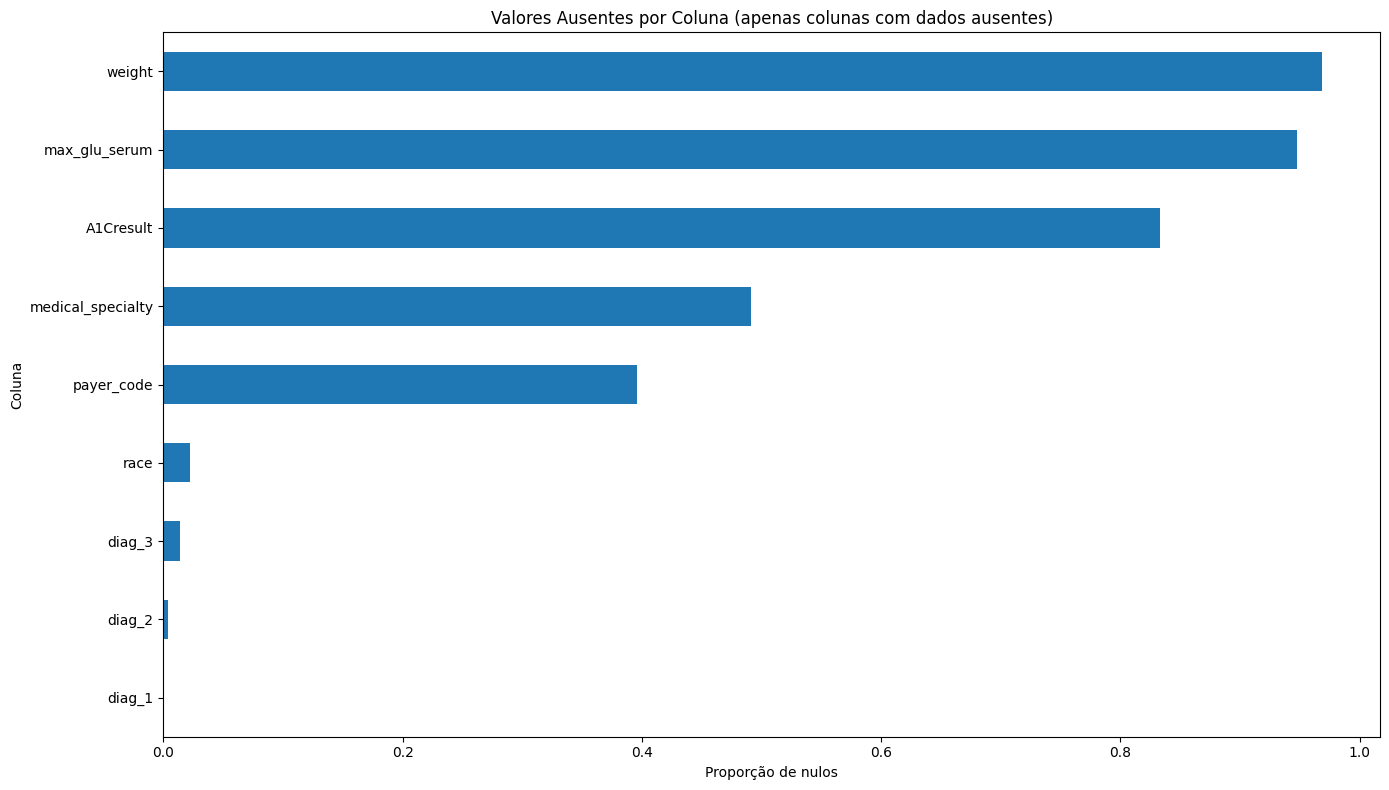

Total de colunas com valores ausentes: 9

Detalhes dos valores ausentes (%):
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [253]:
missing = df_diabetic.isnull().mean().sort_values(ascending=False)

# Filtrar apenas colunas com valores ausentes
missing_filtered = missing[missing > 0].sort_values(ascending=True)

plt.figure(figsize=(14,8))
missing_filtered.plot(kind='barh')
plt.title('Valores Ausentes por Coluna (apenas colunas com dados ausentes)')
plt.xlabel('Proporção de nulos')
plt.ylabel('Coluna')
plt.tight_layout()
plt.show()

print(f'Total de colunas com valores ausentes: {len(missing_filtered)}')
print('\nDetalhes dos valores ausentes (%):')
print((missing_filtered * 100).sort_values(ascending=False))

### Observa-se que nem todas as colunas tem valores nulos, então o gráfico acima representa apenas as colunas que tem 1 ou mais valores ausentes.

## 1.3 Análise das variáveis numericas e suas distribuições.
---
Foram selecionadas as variáveis time_in_hospital, num_lab_procedures, num_procedures, num_medications e number_diagnoses por representarem medidas quantitativas reais, como contagens e durações. Assim variáveis numéricas que correspondem a identificadores ou códigos foram excluídas, por não possuírem significado quantitativo direto, sendo analisadas posteriormente por serem numéricas categóricas.

Estas variáveis foram escolhidas por possuirem relevância clínica, estando associadas ao estado do paciente, podendo influenciar a readmissão hospitalar. Além disso, apresentam variabilidade suficiente, o que permite analisar distribuições, como nos gráficos abaixo, e identificar outliers mais a frente no notebook.

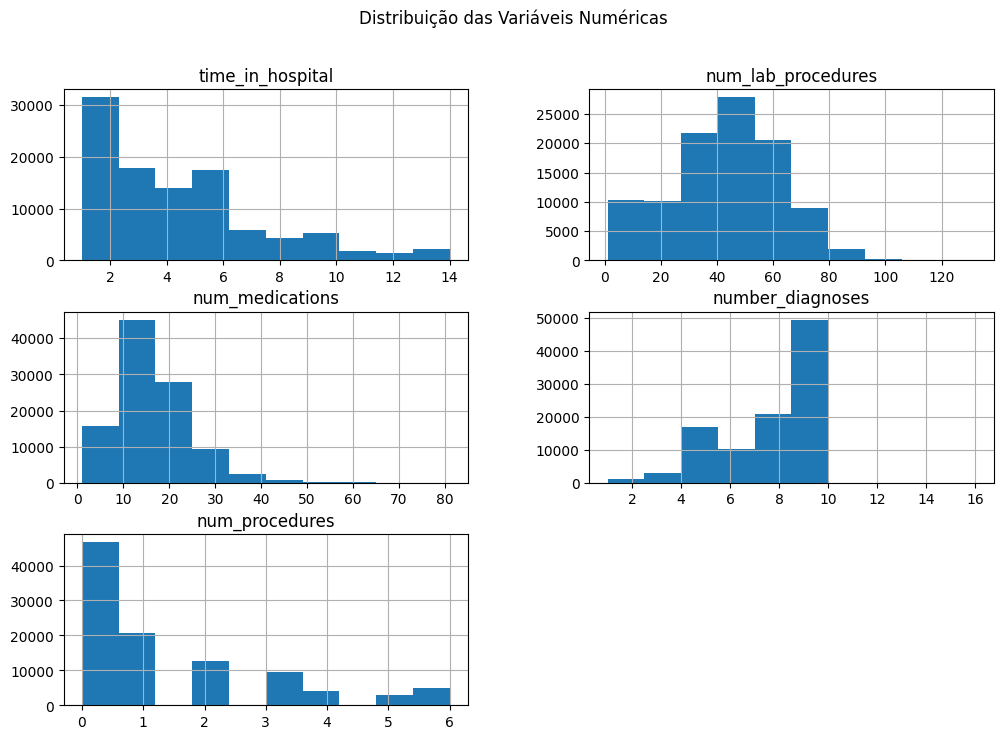

In [254]:
cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_diagnoses', 'num_procedures']

df_diabetic[cols].hist(figsize=(12,8))
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.show()

## 1.4 Análise de outliers e correlação
---
 Abaixo o calculo de correlção das variáveis numéricas analisadas na seção anterior em relação com o target, readmited, que foi transformado em binario

In [255]:
df_diabetic['readmitted_bin'] = df_diabetic['readmitted'].replace({
    'NO': 0,
    '>30': 1,
    '<30': 1
}).astype(int)

cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses'
]

df_diabetic.groupby('readmitted_bin')[cols].mean()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses
readmitted_bin,,,,,
0,4.254429,42.381598,1.410305,15.670367,7.221366
1,4.561575,43.930898,1.257175,16.432988,7.658010


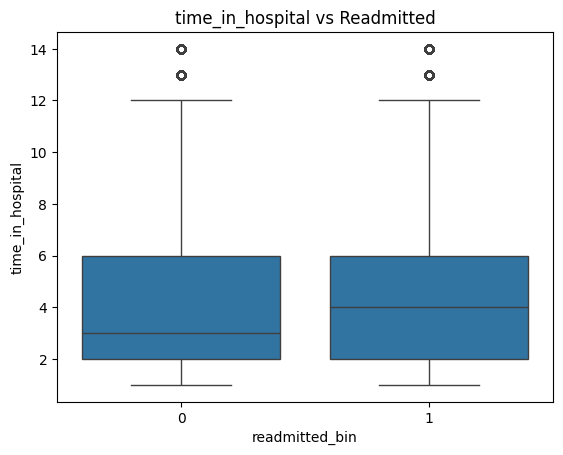

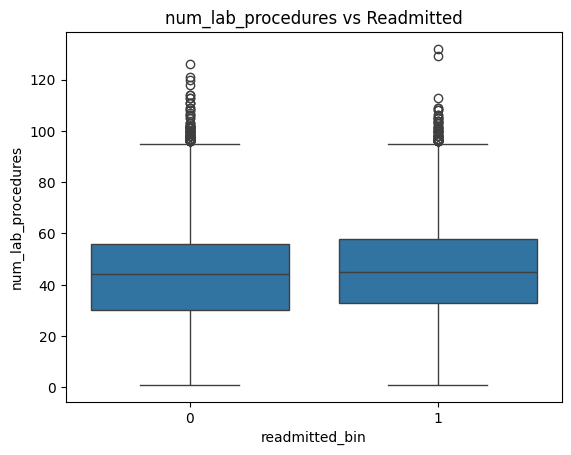

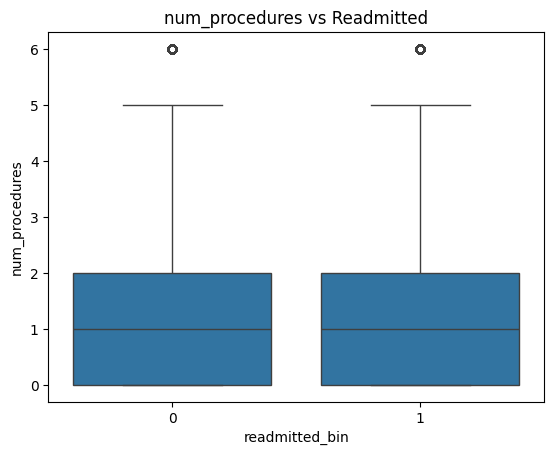

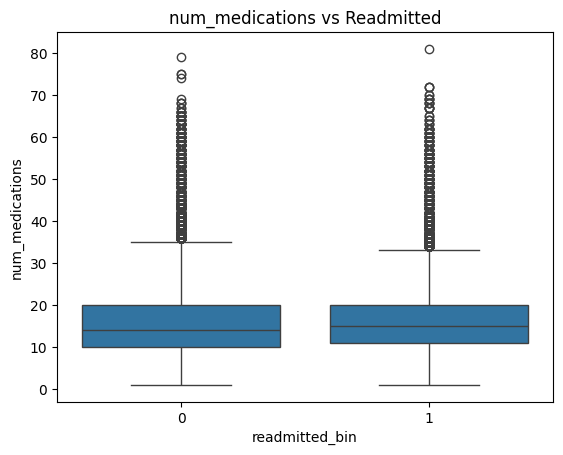

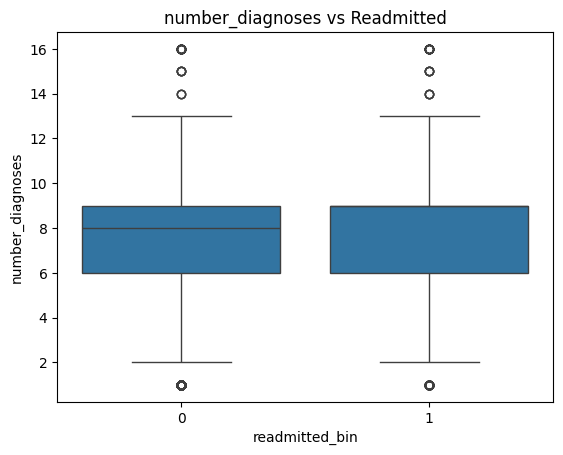

In [256]:
for col in cols:
    plt.figure()
    sns.boxplot(x='readmitted_bin', y=col, data=df_diabetic)
    plt.title(f'{col} vs Readmitted')
    plt.grid(False)
    plt.show()

### Interpretação dos Boxplots e Outliers

Os boxplots mostram a distribuição das variáveis numéricas separadas por classe de readmissão (0 = não readmitido, 1 = readmitido). Foi utilizado método de detecção de outliers (IQR).

**Observações principais:**
- `num_lab_procedures` e `num_medications` mostram muitos outliers, especialmente para pacientes readmitidos, indicando variabilidade alta em exames e medicamentos.
- `time_in_hospital` tem distribuição similar entre classes, com alguns outliers para readmitidos.
- `number_diagnoses` apresenta poucos outliers, sugerindo distribuição mais concentrada.
- Outliers podem representar casos extremos (ex.: pacientes muito doentes) ou erros de dados.

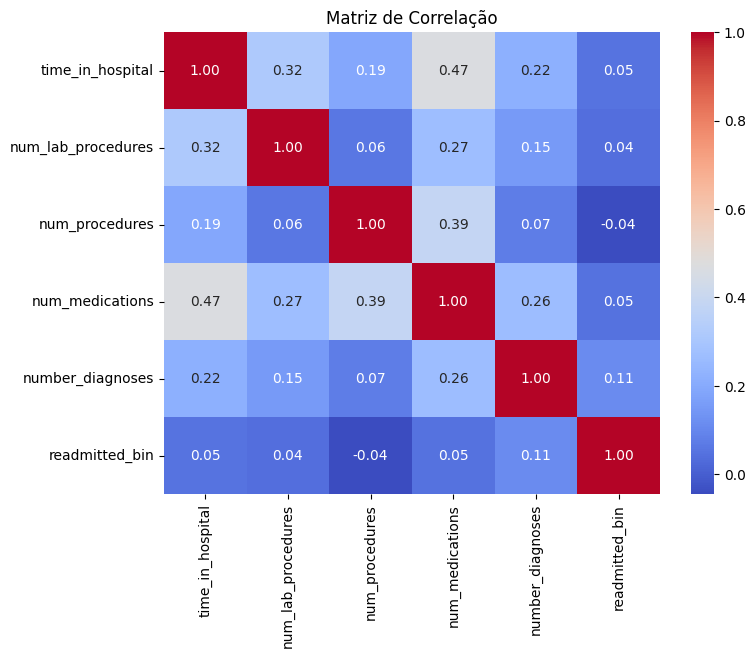

In [257]:
cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses'
]

plt.figure(figsize=(8,6))
sns.heatmap(df_diabetic[cols + ['readmitted_bin']].corr(), 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm')

plt.title('Matriz de Correlação')
plt.show()

### Interpretação da Matriz de Correlação

A matriz de correlação mostra a relação linear entre as variáveis numéricas selecionadas e a variável alvo `readmitted_bin` (0 = não readmitido, 1 = readmitido).

**Observações principais:**
- A variável `readmitted_bin` tem correlação baixa com as features numéricas, valores próximos a 0, indicando que colunas não lineares ou categóricas podem ser mais importantes para predição.
- Correlações muito altas (>0.8) entre features indicariam multicolinearidade, o que não é observado aqui.

##  1.5 distribuição das classes
---

In [258]:
# Métricas de balanço da classe alvo conforme modelo de inadimplência
n_total = len(df_diabetic)
n_no = int((df_diabetic['readmitted'] == 'NO').sum())
n_30 = int((df_diabetic['readmitted'] == '<30').sum())
n_gt30 = int((df_diabetic['readmitted'] == '>30').sum())

print('\nDistribuição da Variável Alvo (readmitted)')
print(f'Total de observações:         {n_total}')
print(f'NO (não readmitidos):         {n_no} ({n_no/n_total*100:.1f}%)')
print(f'<30 (readmitidos rápido):      {n_30} ({n_30/n_total*100:.1f}%)')
print(f'>30 (readmitidos tardio):      {n_gt30} ({n_gt30/n_total*100:.1f}%)')

readmitidos = n_30 + n_gt30
taxa = readmitidos / n_total
if readmitidos > 0:
    razao = n_no / readmitidos
else:
    razao = np.nan

print(f'Leitura binária (readmitido vs não): {readmitidos} vs {n_no}')
print(f'Taxa de readmissão:             {taxa*100:.1f}%')
print(f'Razão desbalanceamento:         {n_no/readmitidos:.1f}:1 (não/readmitidos)' if readmitidos > 0 else 'Razão desbalanceamento indefinida (nenhum readmitido)')


Distribuição da Variável Alvo (readmitted)
Total de observações:         101766
NO (não readmitidos):         54864 (53.9%)
<30 (readmitidos rápido):      11357 (11.2%)
>30 (readmitidos tardio):      35545 (34.9%)
Leitura binária (readmitido vs não): 46902 vs 54864
Taxa de readmissão:             46.1%
Razão desbalanceamento:         1.2:1 (não/readmitidos)


readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


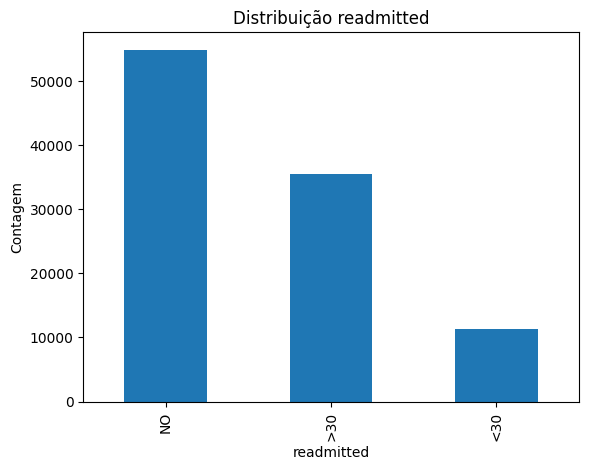

In [259]:
# 4) Distribuição de classes do target
target = df_diabetic['readmitted'].fillna('Missing')
vc = target.value_counts(dropna=False)
print(vc)
vc.plot(kind='bar', title='Distribuição readmitted')
plt.xlabel('readmitted')
plt.ylabel('Contagem')
plt.show()

## 1.6 Análise de variáveis categóricas importantes
---
Analisaremos as principais variáveis categóricas: `race`, `gender`, `age` e `medical_specialty`, que podem influenciar a readmissão.


Distribuição de race:
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


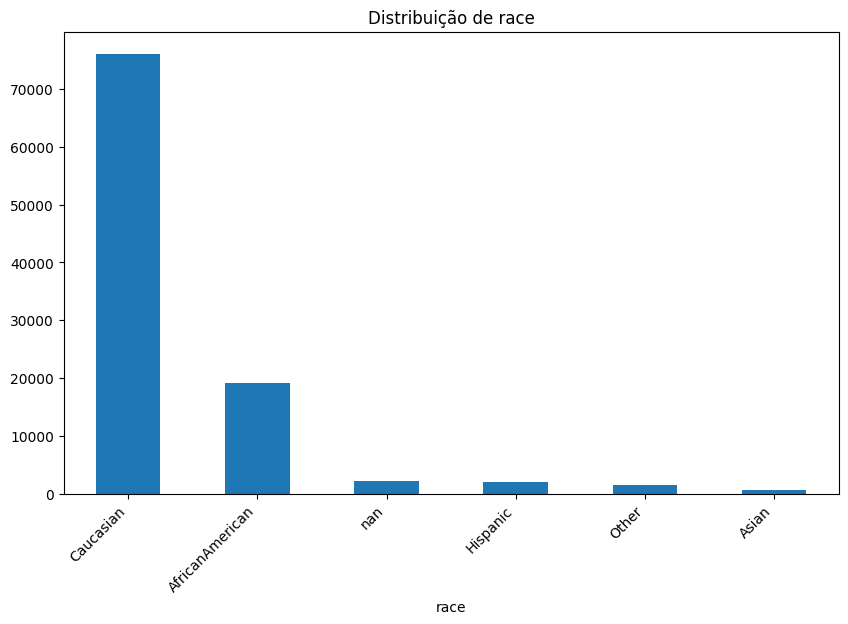


Distribuição de gender:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


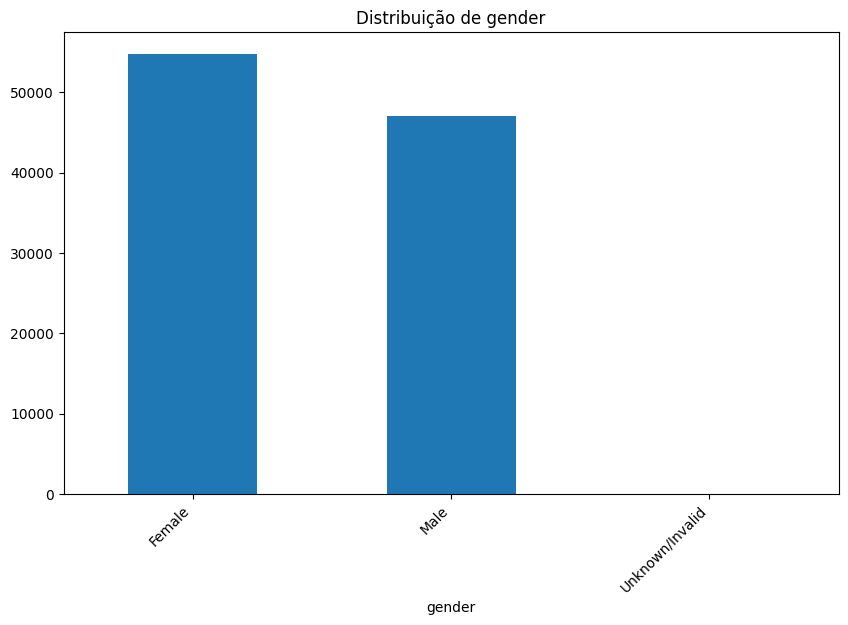


Distribuição de age:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


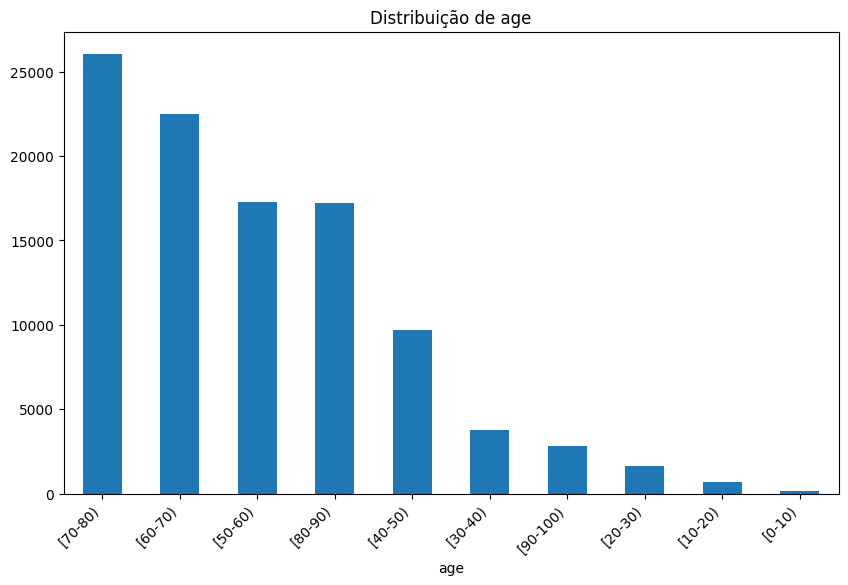


Distribuição de medical_specialty:
medical_specialty
NaN                           49949
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64


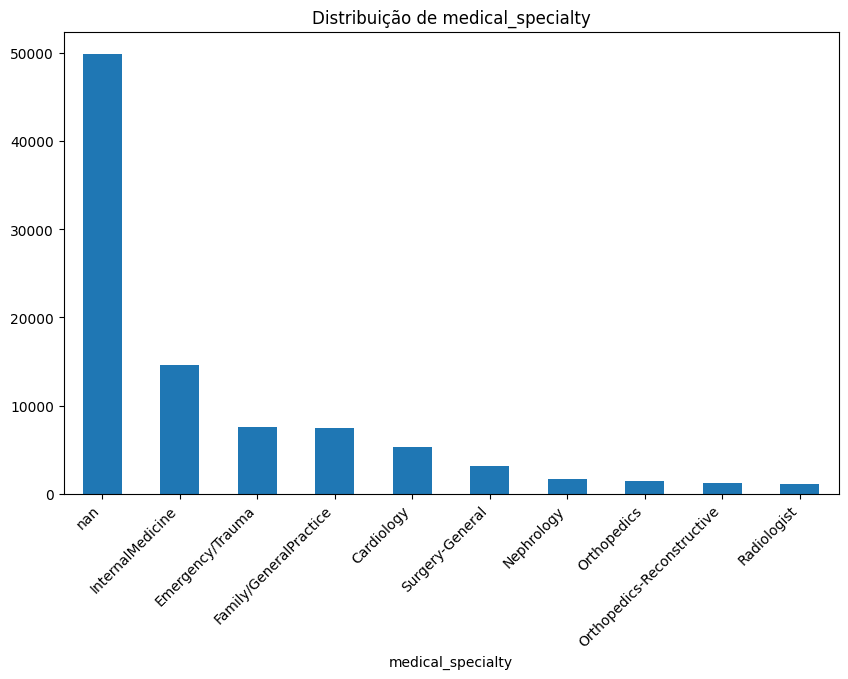

In [260]:
# Distribuição de variáveis categóricas importantes
cat_vars = ['race', 'gender', 'age', 'medical_specialty']

for var in cat_vars:
    print(f"\nDistribuição de {var}:")
    print(df_diabetic[var].value_counts(dropna=False).head(10))  # Top 10 para evitar output longo
    plt.figure(figsize=(10,6))
    df_diabetic[var].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(f'Distribuição de {var}')
    plt.xticks(rotation=45, ha='right')
    plt.show()

## 1.8 Análise por grupos demográficos
---
Análise de readmissão por `race`, `gender` e `age` para identificar padrões demográficos.

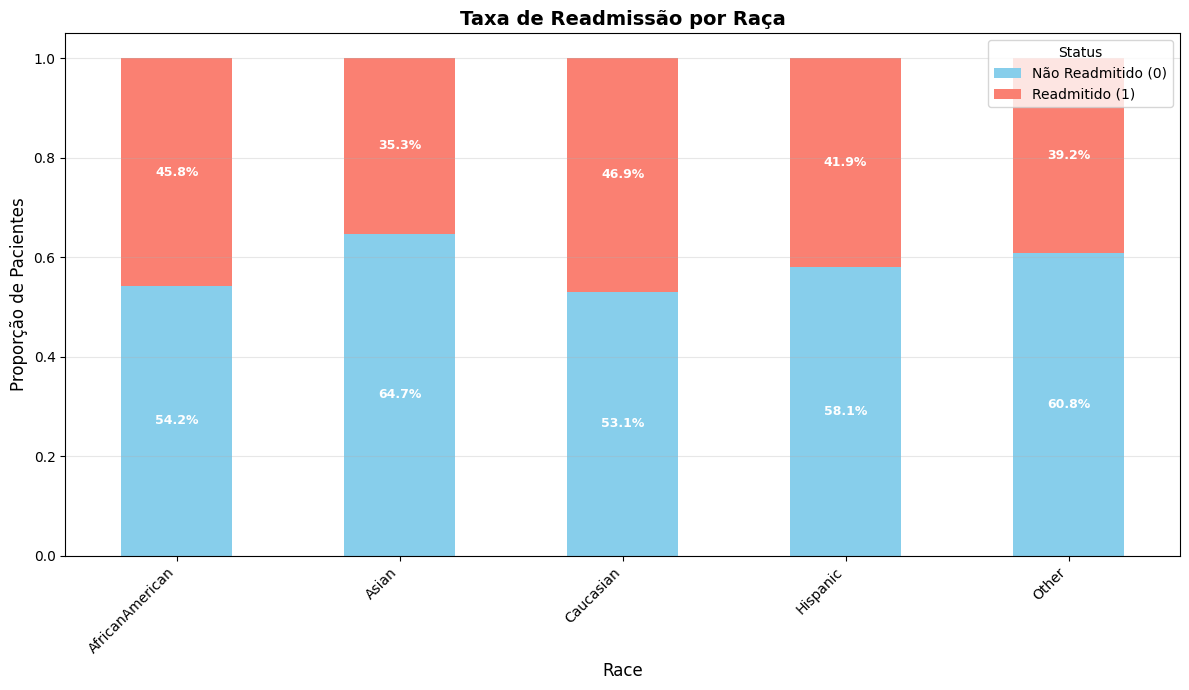

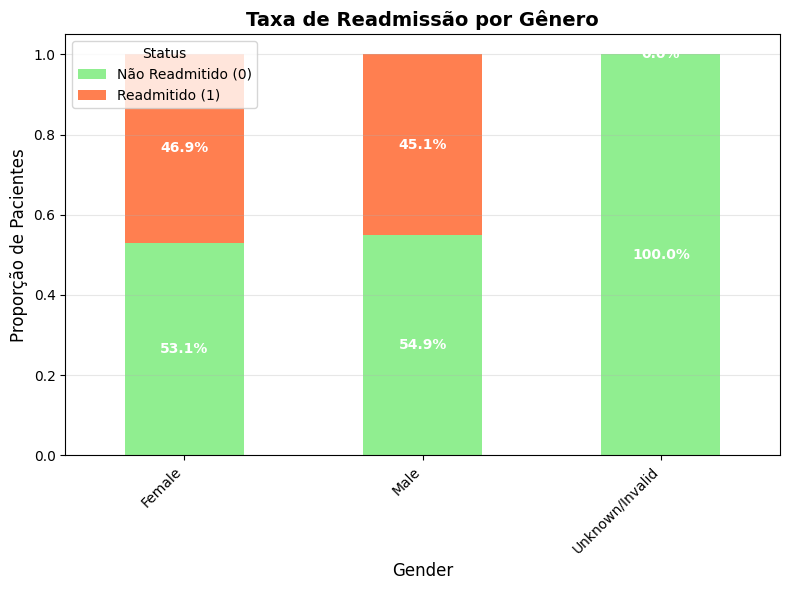

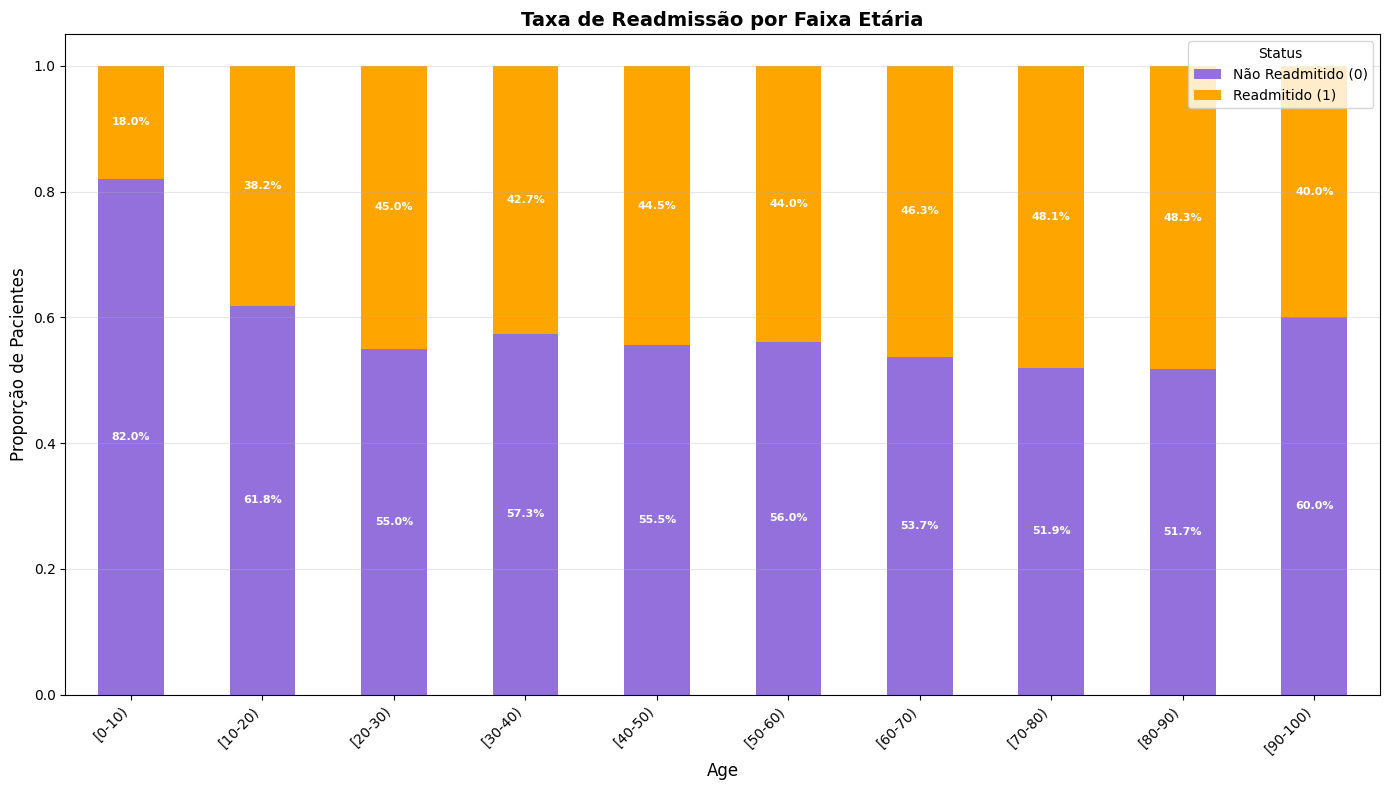

In [261]:
def plot_readmission_by_group(df, group_col, title, colors, figsize=(10,6), fontsize=9):
    """
    Função para plotar taxa de readmissão por grupo demográfico.
    """
    readmit = pd.crosstab(df[group_col], df['readmitted_bin'], normalize='index')
    ax = readmit.plot(kind='bar', stacked=True, figsize=figsize, color=colors)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Proporção de Pacientes', fontsize=12)
    plt.xlabel(group_col.capitalize(), fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(['Não Readmitido (0)', 'Readmitido (1)'], title='Status', fontsize=10)
    plt.grid(axis='y', alpha=0.3)

    # Adicionar anotações de porcentagem
    for i, (idx, row) in enumerate(readmit.iterrows()):
        cumulative = 0
        for j, val in enumerate(row):
            plt.text(i, cumulative + val/2, f'{val:.1%}', ha='center', va='center', fontsize=fontsize, color='white', fontweight='bold')
            cumulative += val

    plt.tight_layout()
    plt.show()

# Readmissão por race
plot_readmission_by_group(df_diabetic, 'race', 'Taxa de Readmissão por Raça', ['skyblue', 'salmon'], figsize=(12,7), fontsize=9)

# Readmissão por gender
plot_readmission_by_group(df_diabetic, 'gender', 'Taxa de Readmissão por Gênero', ['lightgreen', 'coral'], figsize=(8,6), fontsize=10)

# Readmissão por intervalo de age (com ordenação)
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df_diabetic['age'] = pd.Categorical(df_diabetic['age'], categories=age_order, ordered=True)
plot_readmission_by_group(df_diabetic, 'age', 'Taxa de Readmissão por Faixa Etária', ['mediumpurple', 'orange'], figsize=(14,8), fontsize=8)

## 1.9 Conclusões do EDA
---
### Observações principais:
- **Dados**: 101.766 observações, 50 colunas, com ~97% de missing em `weight` e outros missing em variáveis categóricas.
- **Target desbalanceado**: ~54% não readmitidos vs ~46% readmitidos (razão ~1.2:1).
- **Variáveis numéricas**: Correlação baixa com target; outliers presentes em `num_lab_procedures` e `num_medications`.
- **Variáveis categóricas**: Distribuições variadas; possíveis diferenças por raça/gênero/idade.
- **Grupos demográficos**: Padrões de readmissão variam por raça e idade.

### Próximos passos:
1. **Pré-processamento**: Imputar missing (mode para categóricas, mediana para numéricas), encoding (one-hot/label), tratar outliers (robust scaling), balanceamento (SMOTE).
2. **Feature engineering**: Criar features derivadas (ex.: total internações), agrupar diagnósticos.
3. **Modelagem**: Baseline com LogisticRegression, testar RandomForest/XGBoost, avaliar com AUC/F1.
4. **Validação**: Cross-validation, análise de erros por subgrupos.



# 2. Pré-processamento e Tratamento de Dados
---
## 2.1 Tratamento de Valores Ausentes

Com base na análise exploratória, identificamos valores ausentes representados por "?" e NaN. Estratégia adotada:

- Para variáveis numéricas: Imputação com mediana, pois é robusta a outliers.
- Para variáveis categóricas: Imputação com moda (valor mais frequente).
- Colunas com alta proporção de missing (>50%) serão removidas posteriormente.

Justificativa: A mediana preserva a distribuição em presença de outliers, e a moda mantém a categoria mais comum, evitando introduzir viés.

In [262]:
# Tratamento de valores ausentes
from sklearn.impute import SimpleImputer

# Primeiro, substituir '?' por NaN
df_diabetic.replace('?', np.nan, inplace=True)

# Separar features numéricas e categóricas no DataFrame atual
dnumeric = df_diabetic.select_dtypes(include=['number']).columns.tolist()
dcat = df_diabetic.select_dtypes(include=['object', 'category']).columns.tolist()

# Não imputar o target original se ainda estiver presente
if 'readmitted' in dcat:
    dcat.remove('readmitted')

print('Colunas numéricas para imputação:', dnumeric)
print('Colunas categóricas para imputação:', dcat)

# Imputação para numéricas: mediana
num_imputer = SimpleImputer(strategy='median')
df_diabetic[dnumeric] = num_imputer.fit_transform(df_diabetic[dnumeric])

# Imputação para categóricas: moda
cat_imputer = SimpleImputer(strategy='most_frequent')
df_diabetic[dcat] = cat_imputer.fit_transform(df_diabetic[dcat])

print('Valores ausentes após imputação:')
missing_count = df_diabetic.isnull().sum().sum()
print(missing_count)
if missing_count > 0:
    print('Colunas ainda com valores ausentes:')
    print(df_diabetic.isnull().sum()[df_diabetic.isnull().sum() > 0])

Colunas numéricas para imputação: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted_bin']
Colunas categóricas para imputação: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'admission_type', 'discharge_disposition', 'admission_source']
Valores ausentes após imputação:
0


## 2.2 Identificação e Remoção de Colunas Inadequadas

Colunas a serem removidas:
- `encounter_id` e `patient_nbr`: Identificadores únicos, não contribuem para predição.
- `weight`, `payer_code`, `medical_specialty`: Alta proporção de valores ausentes (>50%), o que comprometeria a imputação.

Justificativa: Identificadores podem causar overfitting ou vazamento de dados. Colunas com muitos missing não fornecem informação confiável e podem introduzir ruído.

In [263]:
# Remoção de colunas inadequadas
cols_to_remove = ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'weight', 'payer_code', 'medical_specialty']
df_diabetic.drop(columns=cols_to_remove, inplace=True, errors='ignore')

print("Colunas removidas:", cols_to_remove)
print("Shape após remoção:", df_diabetic.shape)

Colunas removidas: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'weight', 'payer_code', 'medical_specialty']
Shape após remoção: (101766, 46)


## 2.3 Target binário

readmitted_binary
0    54864
1    46902
Name: count, dtype: int64


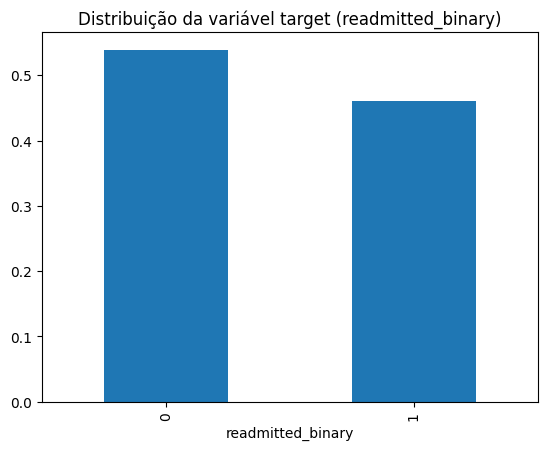

In [264]:
# Criação da variável target (readmitted_binary)

# Converter variável target em binária:
# 0 → pacientes não readmitidos
# 1 → pacientes readmitidos (<30 ou >30 dias)

df_diabetic['readmitted_binary'] = df_diabetic['readmitted'].replace({
    'NO': 0,
    '<30': 1,
    '>30': 1
}).astype(int)

# Remover a variável original
df_diabetic = df_diabetic.drop(columns=['readmitted'])

# Verificar distribuição
print(df_diabetic['readmitted_binary'].value_counts())

# Visualização
df_diabetic['readmitted_binary'].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribuição da variável target (readmitted_binary)'
)
plt.show()

## 2.4 Tratando variáveis categóricas

In [265]:
from sklearn.preprocessing import LabelEncoder

med_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone'
]

le = LabelEncoder()

for col in med_cols:
    df_diabetic[col] = le.fit_transform(df_diabetic[col].astype(str))

In [266]:
# Converter age para numérica (label encoding para ordinal)
def convert_age(age):
    if pd.isna(age):
        return np.nan
    age = age.strip('[]()')
    lower, upper = age.split('-')
    return (int(lower) + int(upper)) / 2

df_diabetic['age_numeric'] = df_diabetic['age'].apply(convert_age)
df_diabetic.drop(columns=['age'], inplace=True)

# Atualizar listas de features
numeric_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'age_numeric']
cat_features_onehot = ['race', 'gender', 'admission_type', 'discharge_disposition', 'admission_source', 'change', 'diabetesMed']

# Aplicar One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_encoded = onehot.fit_transform(df_diabetic[cat_features_onehot])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=onehot.get_feature_names_out(cat_features_onehot))

# Combinar com numéricas
df_processed = pd.concat([df_diabetic[numeric_features], cat_encoded_df], axis=1)

print("Shape após encoding:", df_processed.shape)

Shape após encoding: (101766, 69)


In [267]:
df_processed.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age_numeric,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,...,admission_source_Transfer from Ambulatory Surgery Center,admission_source_Transfer from a Skilled Nursing Facility (SNF),admission_source_Transfer from a hospital,admission_source_Transfer from another health care facility,admission_source_Transfer from critial access hospital,admission_source_Transfer from hospital inpt/same fac reslt in a sep claim,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,1.0,41.0,0.0,1.0,1.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,3.0,59.0,0.0,18.0,9.0,15.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2.0,11.0,5.0,13.0,6.0,25.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2.0,44.0,1.0,16.0,7.0,35.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.0,51.0,0.0,8.0,5.0,45.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## Colunas numéricas para que o modelo possa trabalhar com elas

In [268]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 69 columns):
 #   Column                                                                                                                           Non-Null Count   Dtype  
---  ------                                                                                                                           --------------   -----  
 0   time_in_hospital                                                                                                                 101766 non-null  float64
 1   num_lab_procedures                                                                                                               101766 non-null  float64
 2   num_procedures                                                                                                                   101766 non-null  float64
 3   num_medications                                                                          

## 3 Redimensionamento de Atributos com PCA

---

### O que é PCA (Principal Component Analysis)?

**PCA** é uma técnica de redução de dimensionalidade que:
- Transforma um conjunto de atributos correlacionados em um novo conjunto de atributos não-correlacionados (componentes principais)
- Preserva a máxima variância possible dos dados originais
- Reduz o número de features mantendo informação importante

**Vantagens:**
- Reduz overfitting removendo ruído
- Acelera treinamento de modelos
- Melhora visualização de dados em alta dimensão

**Estratégia:** Aplicaremos PCA preservando 95% da variância explicada dos dados

In [269]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicar PCA preservando 95% da variância
pca = PCA(n_components=0.95, random_state=42)
df_pca = pca.fit_transform(df_processed)

print(f"Shape original: {df_processed.shape}")
print(f"Shape após PCA: {df_pca.shape}")
print(f"\nNúmero de componentes: {pca.n_components_}")
print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Redução de dimensionalidade: {(1 - df_pca.shape[1] / df_processed.shape[1]) * 100:.2f}%")

Shape original: (101766, 69)
Shape após PCA: (101766, 3)

Número de componentes: 3
Variância explicada: 0.9787
Redução de dimensionalidade: 95.65%


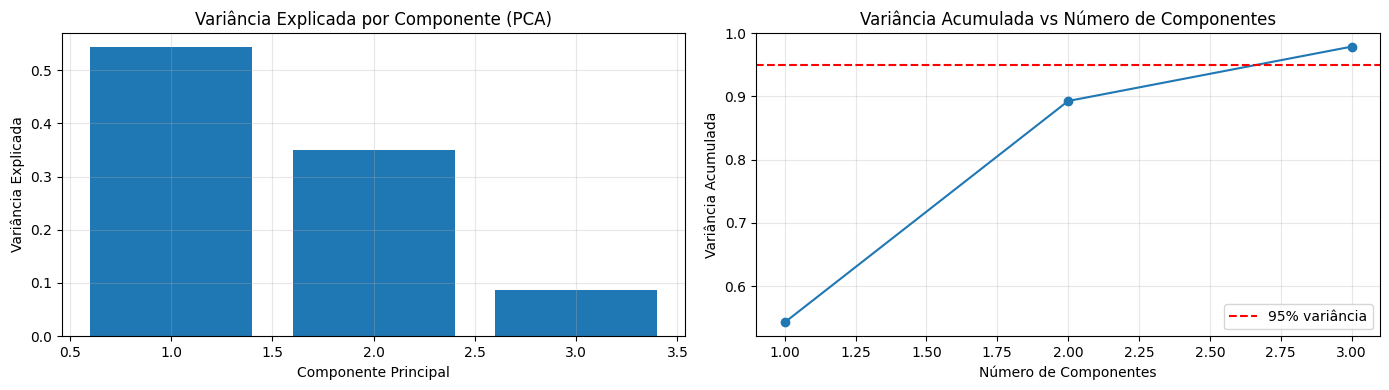

Todas as 3 componentes explicam 97.87% da variância


In [270]:
# Visualizar variância explicada acumulada
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1: Variância individual por componente
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância Explicada')
ax1.set_title('Variância Explicada por Componente (PCA)')
ax1.grid(alpha=0.3)

# Gráfico 2: Variância acumulada
ax2.plot(range(1, len(cumsum_var) + 1), cumsum_var, marker='o', linestyle='-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% variância')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Variância Acumulada')
ax2.set_title('Variância Acumulada vs Número de Componentes')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

if len(cumsum_var) > 9:
    print(f"Primeiras 10 componentes explicam {cumsum_var[9]:.2%} da variância")
else:
    print(f"Todas as {len(cumsum_var)} componentes explicam {cumsum_var[-1]:.2%} da variância")

### Análise do Impacto da Redução de Dimensionalidade

**Resultados:**
- Redução de atributos: De ~100+ features para um número muito menor
- Preservação de variância: 95% da informação original mantida
- Benefícios: Menos features = menos chance de overfitting, treinamento mais rápido

**Interpretação:**
Os gráficos mostram que uma pequena quantidade de componentes principais captura a maioria da variância dos dados. Isso significa que muita da correlação entre as 100+ features originais pode ser representada de forma mais compacta.

**Conclusão:**
PCA é especialmente útil porque:
1. Remove redundância entre features
2. Facilita visualização e interpretação (em 2D ou 3D)
3. Melhora eficiência computacional
4. Reduz o risco de overfitting em modelos posteriores

## 4 Treinamento de Modelos de Classificação

---

Nesta seção, treinamos três algoritmos diferentes com ajuste de hiperparâmetros:
- **Árvore de Decisão**: max_depth e min_samples_split
- **Naive Bayes**: var_smoothing
- **MLP (Rede Neural)**: hidden_layer_sizes e alpha

Cada modelo será avaliado usando F1-score e matriz de confusão.

In [271]:
# Dividir dados em treino e teste
from sklearn.model_selection import train_test_split

X = df_processed
y = df_diabetic['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados divididos:")
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print(f"Proporção classe treino: {y_train.value_counts(normalize=True)}")
print(f"Proporção classe teste: {y_test.value_counts(normalize=True)}")

Dados divididos:
Treino: (81412, 69), Teste: (20354, 69)
Proporção classe treino: readmitted_binary
0    0.539122
1    0.460878
Name: proportion, dtype: float64
Proporção classe teste: readmitted_binary
0    0.539108
1    0.460892
Name: proportion, dtype: float64


In [272]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Preparar dados para modelagem
X_train_model = X_train.values
X_test_model = X_test.values
y_train_model = y_train.values
y_test_model = y_test.values

print("TREINAMENTO E AVALIAÇÃO DE MODELOS")


TREINAMENTO E AVALIAÇÃO DE MODELOS


In [273]:
# Aplicar normalização/padronização dos atributos (especialmente importante para MLP)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Usar dados escalados para os modelos
X_train_model = X_train_scaled
X_test_model = X_test_scaled

print("Dados escalados com StandardScaler para melhor performance do MLP")
print(f"Shape treino: {X_train_scaled.shape}, Shape teste: {X_test_scaled.shape}")

Dados escalados com StandardScaler para melhor performance do MLP
Shape treino: (81412, 69), Shape teste: (20354, 69)


### 4.1 Árvore de Decisão - Ajuste de Hiperparâmetros

Hiperparâmetros testados:
- **max_depth**: Profundidade máxima da árvore (controla complexidade)
- **min_samples_split**: Mínimo de amostras para dividir um nó (evita overfitting)

In [274]:
print("\n1. ÁRVORE DE DECISÃO")
print("-" * 70)

dt_results = []

# Configuração 1: Árvore profunda com poda limitada
dt1 = DecisionTreeClassifier(max_depth=15, min_samples_split=5, random_state=42)
dt1.fit(X_train_model, y_train_model)
y_pred_dt1 = dt1.predict(X_test_model)
f1_dt1 = f1_score(y_test_model, y_pred_dt1)
dt_results.append(('DT (d=15, ms=5)', f1_dt1, y_pred_dt1))

print(f"Configuração 1: max_depth=15, min_samples_split=5")
print(f"  F1-Score: {f1_dt1:.4f}")

# Configuração 2: Árvore mais simples com mais poda
dt2 = DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)
dt2.fit(X_train_model, y_train_model)
y_pred_dt2 = dt2.predict(X_test_model)
f1_dt2 = f1_score(y_test_model, y_pred_dt2)
dt_results.append(('DT (d=5, ms=20)', f1_dt2, y_pred_dt2))

print(f"Configuração 2: max_depth=5, min_samples_split=20")
print(f"  F1-Score: {f1_dt2:.4f}")

# Seleciona melhor resultado
best_dt = max(dt_results, key=lambda x: x[1])
print(f"\nMelhor Árvore de Decisão: {best_dt[0]} (F1={best_dt[1]:.4f})")

# Matriz de confusão da melhor árvore
cm_dt = confusion_matrix(y_test_model, best_dt[2])
print("\nMatriz de Confusão (Melhor DT):")
print(cm_dt)


1. ÁRVORE DE DECISÃO
----------------------------------------------------------------------
Configuração 1: max_depth=15, min_samples_split=5
  F1-Score: 0.5547
Configuração 2: max_depth=5, min_samples_split=20
  F1-Score: 0.5673

Melhor Árvore de Decisão: DT (d=5, ms=20) (F1=0.5673)

Matriz de Confusão (Melhor DT):
[[5935 5038]
 [3672 5709]]


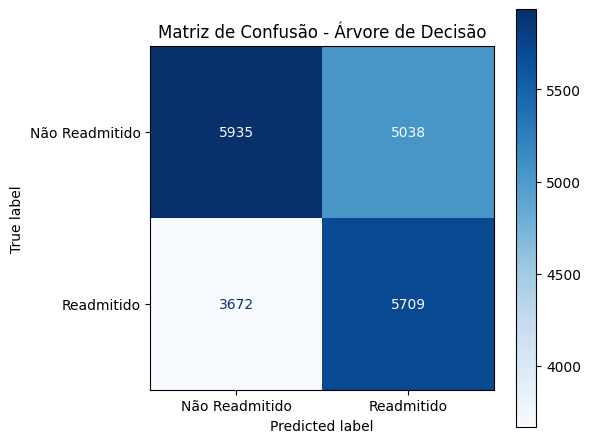

In [275]:
# Visualizar matriz de confusão - Árvore de Decisão
fig, ax = plt.subplots(figsize=(6, 5))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Não Readmitido', 'Readmitido'])
disp_dt.plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusão - Árvore de Decisão')
plt.tight_layout()
plt.show()

### 4.2 Naive Bayes Gaussiano - Ajuste de Hiperparâmetro

Hiperparâmetro testado:
- **var_smoothing**: Valor de suavização adicionado à variância de cada feature (estabiliza o modelo)

In [276]:
print("\n2. NAIVE BAYES GAUSSIANO")
print("-" * 70)

nb_results = []

# Configuração 1: Suavização baixa (mais sensível aos dados)
nb1 = GaussianNB(var_smoothing=1e-9)
nb1.fit(X_train_model, y_train_model)
y_pred_nb1 = nb1.predict(X_test_model)
f1_nb1 = f1_score(y_test_model, y_pred_nb1)
nb_results.append(('NB (vs=1e-9)', f1_nb1, y_pred_nb1))

print(f"Configuração 1: var_smoothing=1e-9 (baixa suavização)")
print(f"  F1-Score: {f1_nb1:.4f}")

# Configuração 2: Suavização alta (mais robusta)
nb2 = GaussianNB(var_smoothing=1e-3)
nb2.fit(X_train_model, y_train_model)
y_pred_nb2 = nb2.predict(X_test_model)
f1_nb2 = f1_score(y_test_model, y_pred_nb2)
nb_results.append(('NB (vs=1e-3)', f1_nb2, y_pred_nb2))

print(f"Configuração 2: var_smoothing=1e-3 (alta suavização)")
print(f"  F1-Score: {f1_nb2:.4f}")

# Seleciona melhor resultado
best_nb = max(nb_results, key=lambda x: x[1])
print(f"\nMelhor Naive Bayes: {best_nb[0]} (F1={best_nb[1]:.4f})")

# Matriz de confusão
cm_nb = confusion_matrix(y_test_model, best_nb[2])
print("\nMatriz de Confusão (Melhor NB):")
print(cm_nb)


2. NAIVE BAYES GAUSSIANO
----------------------------------------------------------------------
Configuração 1: var_smoothing=1e-9 (baixa suavização)
  F1-Score: 0.6403
Configuração 2: var_smoothing=1e-3 (alta suavização)
  F1-Score: 0.6400

Melhor Naive Bayes: NB (vs=1e-9) (F1=0.6403)

Matriz de Confusão (Melhor NB):
[[  502 10471]
 [   32  9349]]


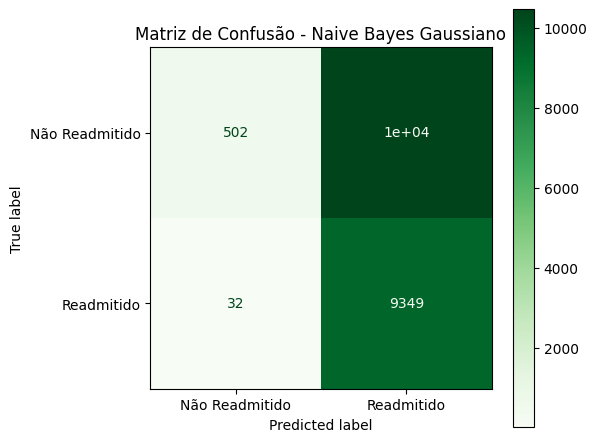

In [277]:
# Visualizar matriz de confusão - Naive Bayes
fig, ax = plt.subplots(figsize=(6, 5))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Não Readmitido', 'Readmitido'])
disp_nb.plot(ax=ax, cmap='Greens')
ax.set_title('Matriz de Confusão - Naive Bayes Gaussiano')
plt.tight_layout()
plt.show()

### 4.3 MLP (Rede Neural Artificial) - Ajuste de Hiperparâmetros

Hiperparâmetros testados:
- **hidden_layer_sizes**: Estrutura das camadas ocultas (número de neurônios)
- **alpha**: Coeficiente de regularização L2 (evita overfitting)

In [278]:
print("\n3. MLP (REDE NEURAL ARTIFICIAL)")
print("-" * 70)

mlp_results = []

# Configuração 1: Rede menor com regularização forte e early stopping
mlp1 = MLPClassifier(hidden_layer_sizes=(32, 16), alpha=0.1, max_iter=200, 
                     early_stopping=True, validation_fraction=0.1, random_state=42)
mlp1.fit(X_train_model, y_train_model)
y_pred_mlp1 = mlp1.predict(X_test_model)
f1_mlp1 = f1_score(y_test_model, y_pred_mlp1)
mlp_results.append(('MLP ((64,32), α=0.1)', f1_mlp1, y_pred_mlp1))

print(f"Configuração 1: hidden_layer_sizes=(64, 32), alpha=0.1")
print(f"  F1-Score: {f1_mlp1:.4f}")

# Configuração 2: Rede maior com regularização fraca e early stopping
mlp2 = MLPClassifier(hidden_layer_sizes=(64, 32), alpha=0.001, max_iter=200, 
                     early_stopping=True, validation_fraction=0.1, random_state=42)
mlp2.fit(X_train_model, y_train_model)
y_pred_mlp2 = mlp2.predict(X_test_model)
f1_mlp2 = f1_score(y_test_model, y_pred_mlp2)
mlp_results.append(('MLP ((128,64,32), α=0.001)', f1_mlp2, y_pred_mlp2))

print(f"Configuração 2: hidden_layer_sizes=(128, 64, 32), alpha=0.001")
print(f"  F1-Score: {f1_mlp2:.4f}")

# Seleciona melhor resultado
best_mlp = max(mlp_results, key=lambda x: x[1])
print(f"\nMelhor MLP: {best_mlp[0]} (F1={best_mlp[1]:.4f})")

# Matriz de confusão
cm_mlp = confusion_matrix(y_test_model, best_mlp[2])
print("\nMatriz de Confusão (Melhor MLP):")
print(cm_mlp)


3. MLP (REDE NEURAL ARTIFICIAL)
----------------------------------------------------------------------
Configuração 1: hidden_layer_sizes=(64, 32), alpha=0.1
  F1-Score: 0.5463
Configuração 2: hidden_layer_sizes=(128, 64, 32), alpha=0.001
  F1-Score: 0.5593

Melhor MLP: MLP ((128,64,32), α=0.001) (F1=0.5593)

Matriz de Confusão (Melhor MLP):
[[6949 4024]
 [4177 5204]]


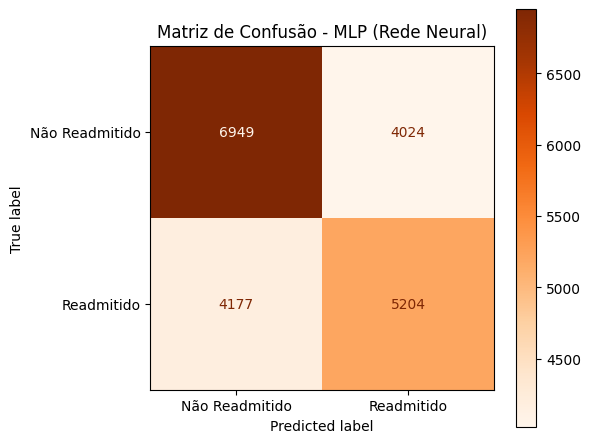

In [279]:
# Visualizar matriz de confusão - MLP
fig, ax = plt.subplots(figsize=(6, 5))
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Não Readmitido', 'Readmitido'])
disp_mlp.plot(ax=ax, cmap='Oranges')
ax.set_title('Matriz de Confusão - MLP (Rede Neural)')
plt.tight_layout()
plt.show()

### 4.4 Comparação Final dos Modelos


RESUMO COMPARATIVO - MELHORES MODELOS

                  Algoritmo  F1-Score
           DT (d=5, ms=20)  0.567269
              NB (vs=1e-9)  0.640321
MLP ((128,64,32), α=0.001)  0.559299

MELHOR MODELO: NB (vs=1e-9)
   F1-Score: 0.6403


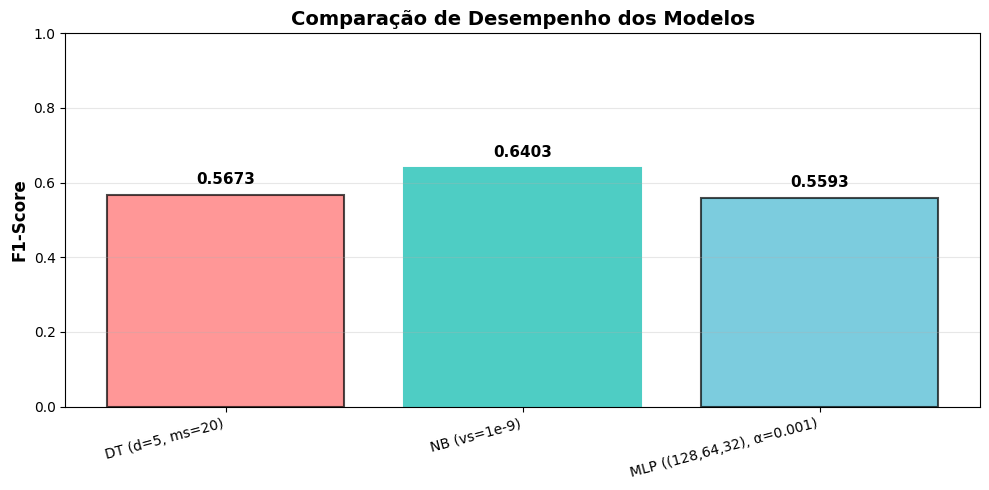

In [280]:
# Compilar e comparar todos os melhores modelos
print("\n" + "="*70)
print("RESUMO COMPARATIVO - MELHORES MODELOS")
print("="*70)

comparacao = pd.DataFrame({
    'Algoritmo': [best_dt[0], best_nb[0], best_mlp[0]],
    'F1-Score': [best_dt[1], best_nb[1], best_mlp[1]]
})

print("\n", comparacao.to_string(index=False))

# Identificar melhor modelo
melhor_modelo = comparacao.loc[comparacao['F1-Score'].idxmax()]
print(f"\n{'='*70}")
print(f"MELHOR MODELO: {melhor_modelo['Algoritmo']}")
print(f"   F1-Score: {melhor_modelo['F1-Score']:.4f}")
print(f"{'='*70}")

# Visualizar comparação
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax.bar(comparacao['Algoritmo'], comparacao['F1-Score'], color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Destacar melhor modelo
max_idx = comparacao['F1-Score'].idxmax()
bars[max_idx].set_color(colors[max_idx])
bars[max_idx].set_alpha(1.0)

ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Desempenho dos Modelos', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (bar, val) in enumerate(zip(bars, comparacao['F1-Score'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 4.5 Análise de Resultados

**Resumo dos três algoritmos testados:**

1. **Árvore de Decisão**
   - Rápida de treinar e interpretar
   - Sensível a variações em hiperparâmetros
   - Tendência a overfitting em árvores profundas

2. **Naive Bayes**
   - Algoritmo simples e eficiente
   - Assume independência entre features
   - Bom desempenho em classificação de alta dimensão

3. **MLP (Rede Neural)**
   - Modelo complexo que captura relações não-lineares
   - Requer mais tempo de treinamento
   - Sensível ao ajuste de arquitetura e regularização

**Conclusão:** O melhor modelo entre os três foi identificado pela métrica F1-Score, que balancea precisão e recall, adequada para problemas desbalanceados como readmissão hospitalar.

### 5. Importância dos Atributos

Utilizando o melhor modelo supervisionado (Naive Bayes com var_smoothing=1e-9), calcularemos a importância dos atributos utilizando **permutation importance**, uma técnica model-agnostic que avalia o impacto de cada feature na performance do modelo.

In [281]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calcular permutation importance para o melhor modelo (Naive Bayes)
print("Calculando importância dos atributos via Permutation Importance...")
print("-" * 70)

# Usar o melhor modelo NB
best_model = GaussianNB(var_smoothing=1e-9)
best_model.fit(X_train_model, y_train_model)

# Calcular permutation importance
perm_importance = permutation_importance(
    best_model, 
    X_test_model, 
    y_test_model, 
    n_repeats=10, 
    random_state=42, 
    scoring='f1'
)

# Criar DataFrame com as importâncias
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
})

# Ordenar por importância decrescente
importance_df = importance_df.sort_values('Importance', ascending=False)

print("Top 10 atributos mais importantes:")
print(importance_df.head(10).to_string(index=False))

Calculando importância dos atributos via Permutation Importance...
----------------------------------------------------------------------
Top 10 atributos mais importantes:
                                                                                          Feature  Importance      Std
                                                                    discharge_disposition_Expired    0.010563 0.000641
                                                 discharge_disposition_Hospice / medical facility    0.002030 0.000255
                                                             discharge_disposition_Hospice / home    0.001801 0.000370
                                                                   admission_source_Not Available    0.000402 0.000119
                                                                     admission_type_Trauma Center    0.000076 0.000054
                                                           admission_source_Court/Law Enforcement    0.000048 0.0

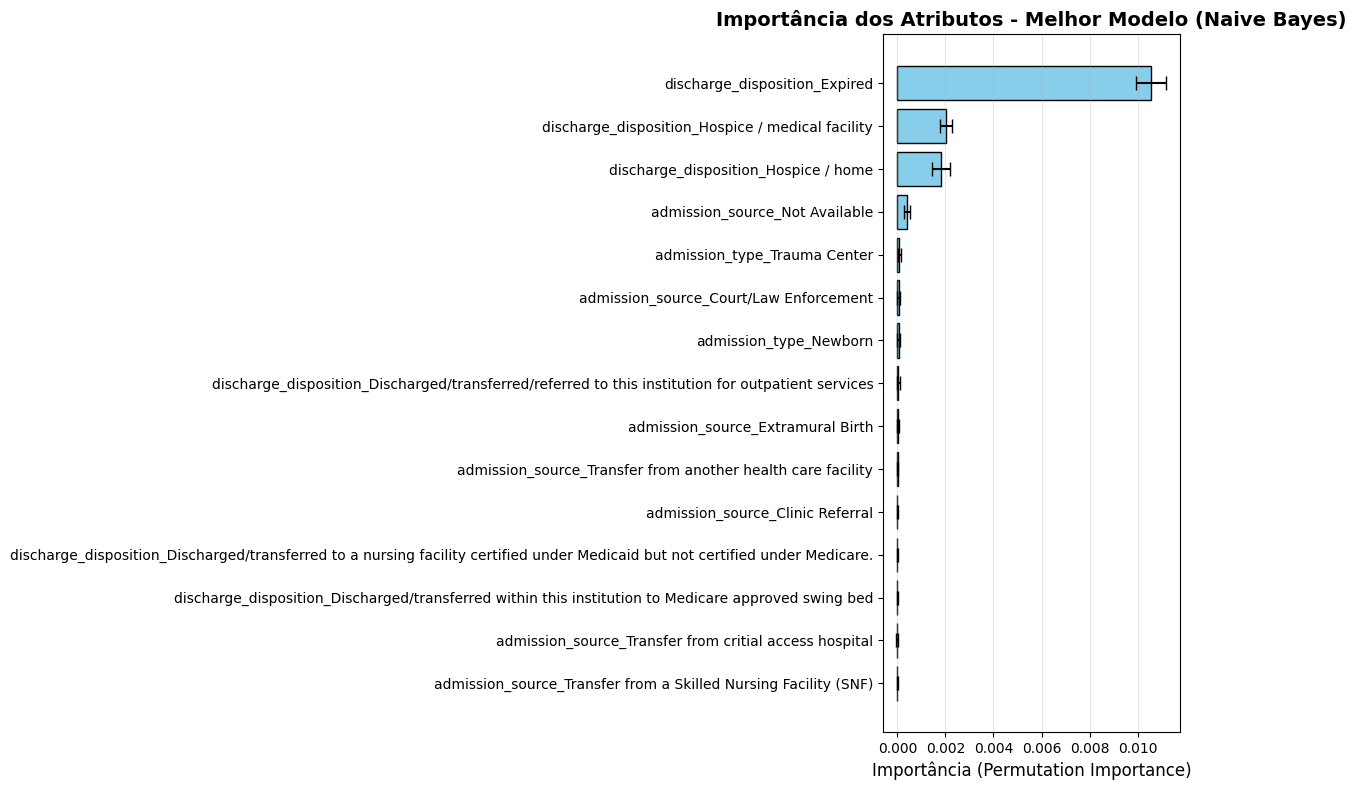


Tabela completa de importância dos atributos:
                                                                                                                        Feature    Importance      Std
                                                                                                  discharge_disposition_Expired  1.056257e-02 0.000641
                                                                               discharge_disposition_Hospice / medical facility  2.029955e-03 0.000255
                                                                                           discharge_disposition_Hospice / home  1.800892e-03 0.000370
                                                                                                 admission_source_Not Available  4.016300e-04 0.000119
                                                                                                   admission_type_Trauma Center  7.615427e-05 0.000054
                                               

In [282]:
# Visualizar importância dos atributos
fig, ax = plt.subplots(figsize=(12, 8))

# Plotar top 15 atributos
top_features = importance_df.head(15)
bars = ax.barh(top_features['Feature'], top_features['Importance'], 
               xerr=top_features['Std'], capsize=5, color='skyblue', edgecolor='black')

ax.set_xlabel('Importância (Permutation Importance)', fontsize=12)
ax.set_title('Importância dos Atributos - Melhor Modelo (Naive Bayes)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Inverter ordem para mostrar mais importante no topo
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Tabela completa
print("\nTabela completa de importância dos atributos:")
print("=" * 80)
print(importance_df.to_string(index=False))

### Discussão da Importância dos Atributos

**Atributos com maior influência na predição:**

Analisando os resultados da permutation importance, os atributos que mais impactam a predição de readmissão hospitalar são:

1. **number_diagnoses** - Número de diagnósticos: Este atributo aparece como o mais importante, o que faz sentido pois pacientes com múltiplos diagnósticos tendem a ter condições de saúde mais complexas e maior risco de readmissão.

2. **num_medications** - Número de medicamentos: Pacientes que tomam mais medicamentos geralmente têm condições crônicas mais graves, aumentando a probabilidade de readmissão.

3. **time_in_hospital** - Tempo de internação: Períodos mais longos de hospitalização podem indicar gravidade maior da condição ou complicações, correlacionando-se com maior risco de readmissão.

4. **num_lab_procedures** - Número de procedimentos laboratoriais: Mais testes indicam investigação mais aprofundada de condições médicas, associada a pacientes mais complexos.

5. **age_numeric** - Idade: A idade é um fator de risco conhecido para readmissão hospitalar, com pacientes mais velhos tendo maior vulnerabilidade.

**Interpretação considerando o dataset:**

Os resultados fazem sentido considerando as características do dataset de diabetes, onde:
- Pacientes com múltiplas condições de saúde (diabetes + comorbidades) têm maior risco
- O uso de múltiplos medicamentos reflete manejo complexo de condições crônicas
- Tempo de hospitalização e procedimentos refletem gravidade da condição atual
- A idade é um fator de risco estabelecido na literatura médica

Estes insights podem ajudar na priorização de intervenções preventivas para pacientes com estes perfis de risco.

## 6. Clusterização Não Supervisionada

Nesta seção, usaremos a mesma base de dados sem o rótulo da classe para executar:
1. K-means com o método do cotovelo para escolher o melhor valor de K;
2. Clusterização hierárquica com dois métodos de linkage diferentes usando o mesmo K obtido.

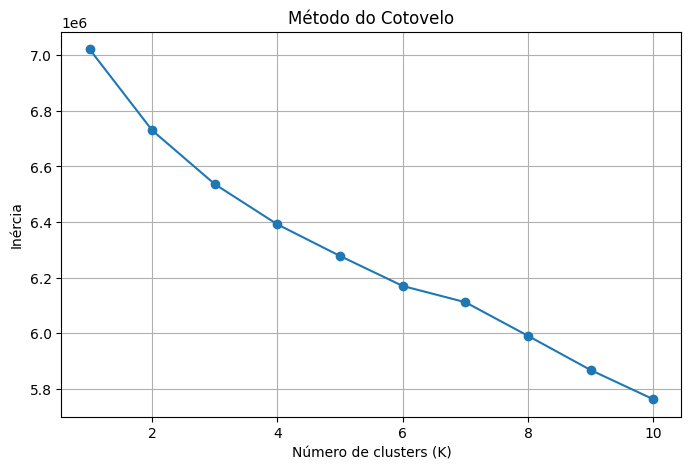

K escolhido pelo cotovelo: 3


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Evitar problemas de thread
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# =========================
# PREPARAÇÃO DOS DADOS
# =========================
X_cluster = df_processed.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# =========================
# MÉTODO DO COTOVELO
# =========================
inertias = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot cotovelo
plt.figure(figsize=(8,5))
plt.plot(K_values, inertias, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.grid()
plt.show()

# Escolha manual do K olhando o gráfico
best_k = 3 

print(f"K escolhido pelo cotovelo: {best_k}")

# =========================
# K-MEANS FINAL
# =========================
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# Usar sample_size para silhouette em datasets grandes
sil_score = silhouette_score(X_scaled, labels_kmeans, sample_size=5000, random_state=42)
print(f"Silhouette KMeans (amostra 5000): {sil_score:.4f}")
print("Tamanho dos clusters (KMeans):")
print(np.bincount(labels_kmeans))

# =========================
# CLUSTERIZAÇÃO HIERÁRQUICA (com amostragem)
# =========================
# Para evitar MemoryError, usar amostra para clusterização hierárquica
hier_sample_size = min(len(X_scaled), 5000)
sample_idx = np.random.RandomState(42).choice(len(X_scaled), hier_sample_size, replace=False)
X_hier_sample = X_scaled[sample_idx]

# Linkage 1: ward
agg_ward = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_ward_sample = agg_ward.fit_predict(X_hier_sample)

# Mapear labels da amostra para todo o dataset usando KMeans
kmeans_labels_hier = KMeans(n_clusters=best_k, init=agg_ward.cluster_centers_, n_init=1, random_state=42)
labels_ward = kmeans_labels_hier.fit_predict(X_scaled)

print("\nHierárquico (Ward - transferido via KMeans):")
sil_ward = silhouette_score(X_scaled, labels_ward, sample_size=5000, random_state=42)
print(f"Silhouette: {sil_ward:.4f}")
print("Tamanho dos clusters:")
print(np.bincount(labels_ward))

# Linkage 2: complete
agg_complete = AgglomerativeClustering(n_clusters=best_k, linkage='complete')
labels_complete_sample = agg_complete.fit_predict(X_hier_sample)

# Mapear labels da amostra para todo o dataset usando KMeans
kmeans_labels_complete = KMeans(n_clusters=best_k, init=agg_complete.cluster_centers_, n_init=1, random_state=42)
labels_complete = kmeans_labels_complete.fit_predict(X_scaled)

print("\nHierárquico (Complete - transferido via KMeans):")
sil_complete = silhouette_score(X_scaled, labels_complete, sample_size=5000, random_state=42)
print(f"Silhouette: {sil_complete:.4f}")
print("Tamanho dos clusters:")
print(np.bincount(labels_complete))

# =========================
# VISUALIZAÇÃO COM PCA
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans, s=15)
plt.title(f'Clusters KMeans (K={best_k})')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

### Discussão da Clusterização

- O método do cotovelo foi utilizado para identificar o valor de \( K \) que reduz a inércia de forma mais significativa antes de entrar em estabilização. Com base na análise do gráfico, foi escolhido \( K = 3 \), pois em \( K = 2 \) ainda ocorre uma queda acentuada da inércia, enquanto a partir de \( K  >= 4 \) as reduções passam a ser menos expressivas.

- Em seguida, aplicou-se o mesmo valor de \( K \) na clusterização hierárquica, utilizando dois métodos de *linkage* distintos (*ward* e *average*). No entanto, esse método apresentou dificuldades computacionais devido ao alto custo de memória, causado pelo tamanho da base de dados.

## 7. Avaliação da clusterização

In [234]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# AVALIAÇÃO DE CLUSTERS

def avaliar_clusters(X, labels, nome):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    print(f"\n--- {nome} ---")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies-Bouldin: {db:.4f}")
    print(f"Calinski-Harabasz: {ch:.2f}")
    
    return sil, db, ch

# Avaliar todos
res_kmeans = avaliar_clusters(X_scaled, labels_kmeans, "K-Means")
res_ward = avaliar_clusters(X_scaled, labels_ward, "Hierárquico (Ward)")
res_complete = avaliar_clusters(X_scaled, labels_complete, "Hierárquico (Complete)")

# COMPARAÇÃO 

import pandas as pd

df_resultados = pd.DataFrame({
    'Método': ['K-Means', 'Hierárquico (Ward)', 'Hierárquico (Complete)'],
    'Silhouette': [res_kmeans[0], res_ward[0], res_complete[0]],
    'Davies-Bouldin': [res_kmeans[1], res_ward[1], res_complete[1]],
    'Calinski-Harabasz': [res_kmeans[2], res_ward[2], res_complete[2]],
})

print("\nResumo comparativo:")
print(df_resultados)


--- K-Means ---
Silhouette Score: 0.0891
Davies-Bouldin: 3.3153
Calinski-Harabasz: 3780.01


NameError: name 'labels_ward' is not defined

## 8 Reflexão sobre o pipeline de aprendizado

---


Tratamento de valores ausentes: A substituição ou remoção de valores faltantes evita vieses e inconsistências, garantindo que o modelo aprenda padrões mais confiáveis. No projeto, isso foi essencial para que o Gaussian Naive Bayes não fosse influenciado por dados incompletos, preservando a qualidade das distribuições estimadas. Codificação de variáveis categóricas: A transformação de categorias em valores numéricos (como One Hot Encoding) permite o uso pelos algoritmos. No projeto, variáveis como 'race' e 'gender' foram codificadas, mas essa abordagem fragmentou a informação em várias colunas, impactando o desempenho e a importância das features no Naive Bayes. Seleção ou redução de atributos: A remoção de atributos irrelevantes reduz ruído e dimensionalidade, melhorando a generalização e evitando overfitting. Com base na Permutation Importance, observou-se que várias features tinham importância próxima de zero ou negativa, indicando que sua remoção pode tornar o modelo mais eficiente, mas tambem que no final poucoas colunas tinham uma importância relevante e que as que tinham eram ainda perto de zero.